In [1]:
import torch

from utils.checkpoints import load_ae_from_path, load_cspn_from_path
from visualisation import show, plot_latent_comparison
from utils.config import DatasetConfig
from dataset_loaders import build_data_loaders
from pathlib import Path


In [2]:
ae_path = Path("../checkpoints/autoencoder/mnist.pt")
ae = load_ae_from_path(ae_path)


In [3]:
dataset_cfg = DatasetConfig(
    name="mnist",
    channels=3,
    height=28,
    width=28,
    num_classes=10,
    num_workers=1
)

dataloader, _ = build_data_loaders(dataset_cfg, batch_size=64)


In [4]:
cspn_spf_path = Path("../checkpoints/cspn/mnist_spflow_test.pt")
cspn_spf = load_cspn_from_path(cspn_spf_path)

In [6]:
cspn_custom_path = Path("../checkpoints/cspn/mnist_custom_test.pt")
cspn_custom = load_cspn_from_path(cspn_custom_path)

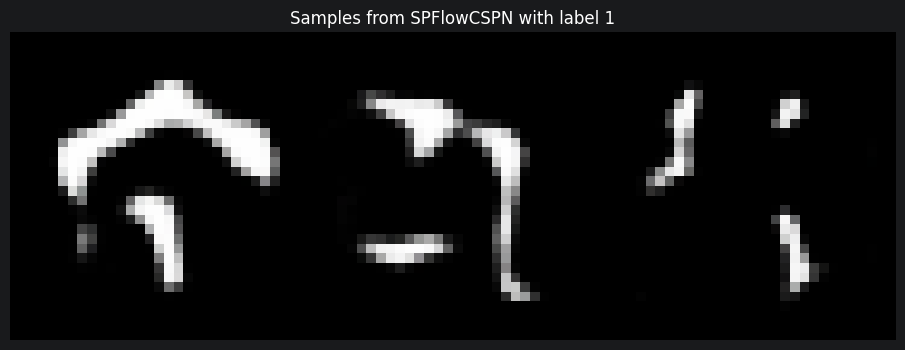

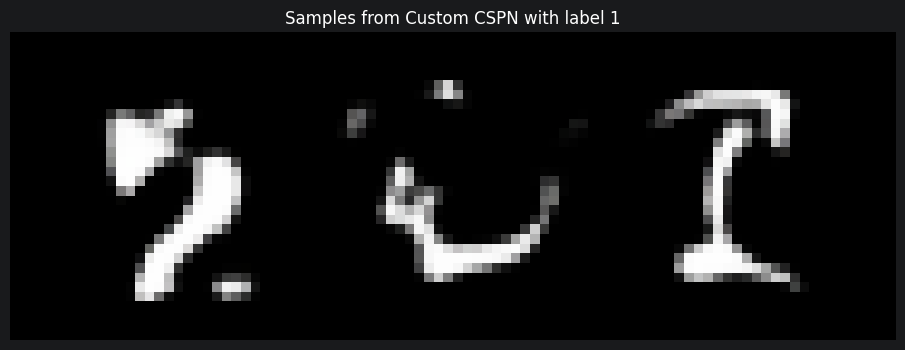

In [7]:
label = 1
sample_labels = torch.tensor([label] * 3)

with torch.no_grad():
    samples_spf = cspn_spf.sample(sample_labels)
    sampled_images_spf = ae.decode(samples_spf)
    samples_custom = cspn_custom.sample(sample_labels)
    sampled_images_custom = ae.decode(samples_custom)

show(sampled_images_spf, f"Samples from SPFlowCSPN with label {label}")
show(sampled_images_custom, f"Samples from Custom CSPN with label {label}")

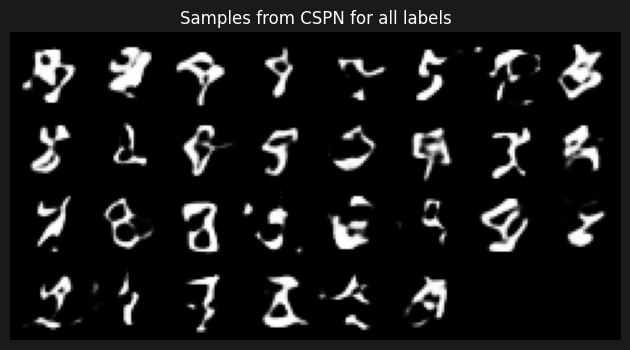

In [8]:
all_labels = torch.arange(10).repeat_interleave(3)

with torch.no_grad():
    samples = cspn_custom.sample(all_labels)
    sampled_images = ae.decode(samples)

show(sampled_images, "Samples from CSPN for all labels")

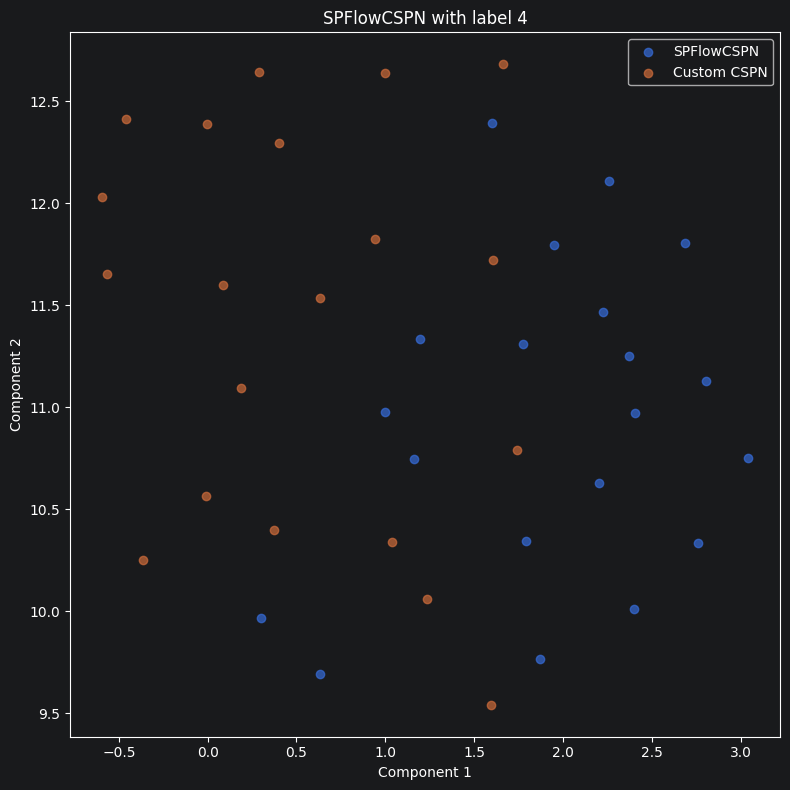

In [9]:
comparison_label = 4
comparison_labels = torch.tensor([comparison_label] * 20)

with torch.no_grad():
    samples_spf = cspn_spf.sample(comparison_labels)
    sampled_images_spf = ae.decode(samples_spf)
    samples_custom = cspn_custom.sample(comparison_labels)
    sampled_images_custom = ae.decode(samples_custom)

plot_latent_comparison(latents_a=samples_spf, latents_b=samples_custom, name_a="SPFlowCSPN", name_b="Custom CSPN",
                       title=f"SPFlowCSPN with label {comparison_label}")
